# ResNet1D ECG — Clasificación Multilabel de Patologías Cardiopulmonares
## TFM: Sistema de Apoyo a la Decisión Clínica Multimodal — Módulo de ECG
### Universidad de Salamanca · Máster en Análisis Avanzado de Datos Multivariantes y Big Data

---

## Descripción general

Este notebook implementa el **modelo de señales ECG** del sistema multimodal para predicción
de patologías cardiopulmonares sobre el dataset **Symile-MIMIC**.

Las señales ECG **no se leen desde disco como archivos sueltos**, sino desde los arrays
preprocesados `ecg_train.npy / ecg_val.npy / ecg_test.npy`. El CSV contiene la columna
`ecg_path` como identificador para el join con el npy por `hadm_id`.

---

### Arquitectura del modelo ECG

```
ecg_train.npy  →  [N, 1, 5000, 12]  →  reordenar a  [N, 12, 5000]
        |
  ResNet1D (bloques residuales Conv1d, 4 etapas: 64→128→256→512 filtros)
        |
   GlobalAvgPool1d → [B, 512]
        |
  Proyección [512→256]          Rama metadatos [META_DIM→64]
        |___________________________________|
           Concatenación [320]
                |
           Head lineal → [B, 6]  logits
                |
    Módulo correlación 6×6 (aprendible, skip connection)
                |
             Sigmoid → probabilidades
```

---

### Etiquetas (multilabel, 6 clases)

| Etiqueta         | Desequilibrio | SPW recomendado | Estrategia              |
|------------------|---------------|-----------------|-------------------------|
| Atelectasis      | 24:1          | 0.04            | Masked BCE + FocalLoss  |
| Cardiomegaly     | 4:1           | 0.30            | Masked BCE              |
| Edema            | ~1.2:1        | 0.90            | Masked BCE              |
| Lung Opacity     | 18:1          | 0.10            | Masked BCE + FocalLoss  |
| No Finding       | sin negativos | N/A             | Etiqueta derivada       |
| Pleural Effusion | 2:1           | 0.50            | Masked BCE              |

---

### Metodología: Estrategia de masking (Sección 6.1)

La estrategia central es el entrenamiento con **máscara de observación** (*masked Binary Cross-Entropy*).
Para cada par (registro *i*, etiqueta *j*) se define:

$$M_{ij} = \begin{cases} 1 & \text{si } y_{ij} \in \{0, 1\} \\ 0 & \text{si } y_{ij} \in \{\text{NaN}, -1\} \end{cases}$$

$$\mathcal{L} = \frac{\sum_{i,j} M_{ij} \cdot \text{BCE}(\hat{y}_{ij},\, y_{ij})}{\sum_{i,j} M_{ij}}$$

Los valores **−1** (incertidumbre clínica) son tratados como **no observados** (Opción A: máscara = 0),
siguiendo la estrategia **U-ignore** de CheXpert.

## Celda 1 — Instalación de dependencias

In [15]:
import subprocess, sys

packages = [
    'scikit-learn',
    'pandas',
    'numpy',
    'matplotlib',
    'seaborn',
    'tqdm',
]

for pkg in packages:
    subprocess.run([sys.executable, '-m', 'pip', 'install', pkg, '-q'], check=True)

print('Dependencias instaladas.')

Dependencias instaladas.


## Celda 2 — Imports, semilla y dispositivo

In [16]:
import os, gc, warnings, random, json, copy, time
from pathlib import Path
from itertools import product as itertools_product

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import KFold
from sklearn.metrics import roc_auc_score, average_precision_score, f1_score

warnings.filterwarnings('ignore')

# ── Reproducibilidad ─────────────────────────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Dispositivo : {DEVICE}')
print(f'PyTorch     : {torch.__version__}')
if torch.cuda.is_available():
    print(f'GPU         : {torch.cuda.get_device_name(0)}')
    print(f'VRAM        : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')
else:
    print('Ejecutando en CPU — entrenamiento lento. Se recomienda GPU.')

Dispositivo : cpu
PyTorch     : 2.8.0+cpu
Ejecutando en CPU — entrenamiento lento. Se recomienda GPU.


## Celda 3 — Constantes globales y rutas

Ajusta `BASE_DATA_DIR` a la ruta local donde residen los ficheros del dataset Symile-MIMIC.

In [17]:
from pathlib import Path

BASE_DATA_DIR = Path(
    r'C:\TFM\1.OPCIÓN - SYMILE MIMIC'
    r'\SYMILE-MIMIC-A-MULTIMODAL-CLINICAL-DATASET-OF-CHEST-X-RAYS-'
    r'ELECTROCARDIOGRAMS-AND-BLOOD-LABS-FROM-MIMIC-IV-1.0.0'
)

# ── Rutas de CSV limpios ──────────────────────────────────────────────────────
CSV_DIR   = BASE_DATA_DIR / 'data_csv' / 'clean'
TRAIN_CSV = CSV_DIR / 'train_clean.csv'
VAL_CSV   = CSV_DIR / 'val_clean.csv'
TEST_CSV  = CSV_DIR / 'test_clean.csv'

# ── Rutas de arrays npy ───────────────────────────────────────────────────────
NPY_DIR        = BASE_DATA_DIR / 'data_npy'
ECG_TRAIN_NPY  = NPY_DIR / 'train' / 'ecg_train.npy'
ECG_VAL_NPY    = NPY_DIR / 'val'   / 'ecg_val.npy'
ECG_TEST_NPY   = NPY_DIR / 'test'  / 'ecg_test.npy'
HADM_TRAIN_NPY = NPY_DIR / 'train' / 'hadm_id_train.npy'
HADM_VAL_NPY   = NPY_DIR / 'val'   / 'hadm_id_val.npy'
HADM_TEST_NPY  = NPY_DIR / 'test'  / 'hadm_id_test.npy'

OUTPUT_DIR = Path('outputs_resnet1d_ecg')
OUTPUT_DIR.mkdir(exist_ok=True)

# ── Etiquetas y pesos positivos ───────────────────────────────────────────────
LABELS   = ['Atelectasis', 'Cardiomegaly', 'Edema', 'Lung Opacity', 'No Finding', 'Pleural Effusion']
N_LABELS = len(LABELS)

# Pesos positivos para BCE: inversamente proporcionales al ratio positivo observado
POS_WEIGHTS = {
    'Atelectasis'     : 0.04,
    'Cardiomegaly'    : 0.30,
    'Edema'           : 0.90,
    'Lung Opacity'    : 0.10,
    'No Finding'      : 1.00,
    'Pleural Effusion': 0.50,
}

# ── Configuración de señal ECG ────────────────────────────────────────────────
ECG_LEADS    = 12
ECG_LENGTH   = 5000
ECG_IN_SHAPE = (ECG_LEADS, ECG_LENGTH)  # shape esperado tras reordenamiento

# ── Codificación de metadatos demográficos ────────────────────────────────────
GENDER_MAP = {0: 0, 1: 1}
RACE_MAP   = {
    'UNKNOWN': 0, 'WHITE': 1, 'BLACK': 2,
    'ASIAN': 3, 'HISPANIC_LATINO': 4, 'OTHER_KNOWN': 5,
}
ADMISSION_MAP = {'SCHEDULED': 0, 'EMERGENCY': 1, 'OBSERVATION': 2, 'URGENT': 3}

# edad + sexo (2) + raza one-hot (6) + tipo de admisión one-hot (4) = 12 dims
META_DIM   = 12
META_EMBED = 64   # dimensión de salida de la rama de metadatos
ECG_PROJ   = 256  # dimensión de la proyección del backbone

# ── Verificación de rutas ─────────────────────────────────────────────────────
print('Verificando rutas...')
all_ok = True
for p in [TRAIN_CSV, VAL_CSV, TEST_CSV,
          ECG_TRAIN_NPY, ECG_VAL_NPY, ECG_TEST_NPY,
          HADM_TRAIN_NPY, HADM_VAL_NPY, HADM_TEST_NPY]:
    exists = p.exists()
    print(f'  {"✓" if exists else "✗ NO ENCONTRADO"}  {p.name}')
    if not exists:
        all_ok = False

if all_ok:
    print('\nConstantes y rutas configuradas correctamente.')
else:
    print('\n⚠️  Algunas rutas no existen. Revisa BASE_DATA_DIR.')

print(f'\nECG input shape : {ECG_IN_SHAPE}')
print(f'META_DIM        : {META_DIM}')

Verificando rutas...
  ✓  train_clean.csv
  ✓  val_clean.csv
  ✓  test_clean.csv
  ✓  ecg_train.npy
  ✓  ecg_val.npy
  ✓  ecg_test.npy
  ✓  hadm_id_train.npy
  ✓  hadm_id_val.npy
  ✓  hadm_id_test.npy

Constantes y rutas configuradas correctamente.

ECG input shape : (12, 5000)
META_DIM        : 12


## Celda 4 — Carga y alineamiento de datos (CSV ↔ npy por `hadm_id`)

Función robusta que maneja test sets reducidos (~1/10 del original en Symile-MIMIC).

In [18]:
def load_split(csv_path, ecg_npy_path, hadm_npy_path, split_name='train'):
    """
    Carga un split alineando CSV y npy de ECG por hadm_id.
    
    Parámetros
    ----------
    csv_path      : Path al CSV limpio del split.
    ecg_npy_path  : Path al array ECG (.npy) del split.
    hadm_npy_path : Path al array de hadm_id (.npy) del split.
    split_name    : Nombre descriptivo para los logs ('train' / 'val' / 'test').
    
    Retorna
    -------
    df              : DataFrame con columna '_npy_idx' que apunta a la fila del npy.
    ecg_npy         : Array ECG cargado en modo mmap (lectura eficiente).
    hadm_to_npy_idx : Diccionario {hadm_id -> índice en npy}.
    """
    print(f'\nCargando split {split_name}')

    df = pd.read_csv(csv_path, sep=';')
    print(f'  CSV filas         : {len(df):,}')

    hadm_npy = np.load(hadm_npy_path, allow_pickle=True)
    print(f'  npy hadm_id count : {len(hadm_npy):,}')

    # Mapa hadm_id → índice en el array npy
    hadm_to_npy_idx = {int(h): i for i, h in enumerate(hadm_npy)}

    # Añadir columna con índice npy; -1 si no existe en el npy
    df['_npy_idx'] = df['hadm_id'].apply(lambda h: hadm_to_npy_idx.get(int(h), -1))
    n_before = len(df)
    df = df[df['_npy_idx'] >= 0].reset_index(drop=True)
    n_descartadas = n_before - len(df)

    if n_descartadas > 0:
        print(f'  Filas con ECG     : {len(df):,}  '
              f'(descartadas sin ECG en npy: {n_descartadas})')
    else:
        print(f'  Filas con ECG     : {len(df):,}  (todas alineadas correctamente)')

    # El test set oficial del dataset fue reducido a ~1/10 durante la limpieza
    if split_name == 'test' and len(df) < 1000:
        print(f'  ⚠️  Test reducido  : {len(df):,} muestras '
              f'(≈1/10 del original). Normal en este dataset.')

    print(f'  Cargando {ecg_npy_path.name} ...', end=' ', flush=True)
    ecg_npy = np.load(ecg_npy_path, mmap_mode='r')
    # ── FIX: garantizar float32 independientemente del dtype original del npy ──
    if ecg_npy.dtype != np.float32:
        print(f'  ⚠️  dtype={ecg_npy.dtype} → convirtiendo a float32...', end=' ')
        ecg_npy = ecg_npy.astype(np.float32)
    print(f'shape={ecg_npy.shape}  dtype={ecg_npy.dtype}')

    # Validación: todos los _npy_idx deben estar dentro del rango del array
    max_idx = df['_npy_idx'].max()
    if max_idx >= len(ecg_npy):
        raise ValueError(
            f'[{split_name}] _npy_idx máximo ({max_idx}) fuera del rango '
            f'del array ECG ({len(ecg_npy)} filas). '
            f'Verifica que hadm_npy y ecg_npy corresponden al mismo split.'
        )

    return df, ecg_npy, hadm_to_npy_idx


# ── Carga de los tres splits ──────────────────────────────────────────────────
df_train, ecg_train_npy, hadm_to_npy_train = load_split(
    TRAIN_CSV, ECG_TRAIN_NPY, HADM_TRAIN_NPY, 'train'
)
df_val, ecg_val_npy, hadm_to_npy_val = load_split(
    VAL_CSV, ECG_VAL_NPY, HADM_VAL_NPY, 'val'
)
df_test, ecg_test_npy, hadm_to_npy_test = load_split(
    TEST_CSV, ECG_TEST_NPY, HADM_TEST_NPY, 'test'
)

print(f'\nDatos ECG cargados:')
print(f'  Train : {len(df_train):,} muestras  |  ECG npy shape: {ecg_train_npy.shape}')
print(f'  Val   : {len(df_val):,} muestras  |  ECG npy shape: {ecg_val_npy.shape}')
print(f'  Test  : {len(df_test):,} muestras  |  ECG npy shape: {ecg_test_npy.shape}')

sample_ecg = ecg_train_npy[0]
print(f'\n  Muestra npy[0]: shape={sample_ecg.shape}  '
      f'min={float(sample_ecg.min()):.3f}  '
      f'max={float(sample_ecg.max()):.3f}  '
      f'mean={float(sample_ecg.mean()):.3f}')


Cargando split train
  CSV filas         : 10,000
  npy hadm_id count : 10,000
  Filas con ECG     : 10,000  (todas alineadas correctamente)
  Cargando ecg_train.npy ... shape=(10000, 1, 5000, 12)  dtype=float32

Cargando split val
  CSV filas         : 750
  npy hadm_id count : 750
  Filas con ECG     : 750  (todas alineadas correctamente)
  Cargando ecg_val.npy ... shape=(750, 1, 5000, 12)  dtype=float32

Cargando split test
  CSV filas         : 464
  npy hadm_id count : 4,640
  Filas con ECG     : 464  (todas alineadas correctamente)
  ⚠️  Test reducido  : 464 muestras (≈1/10 del original). Normal en este dataset.
  Cargando ecg_test.npy ... shape=(4640, 1, 5000, 12)  dtype=float32

Datos ECG cargados:
  Train : 10,000 muestras  |  ECG npy shape: (10000, 1, 5000, 12)
  Val   : 750 muestras  |  ECG npy shape: (750, 1, 5000, 12)
  Test  : 464 muestras  |  ECG npy shape: (4640, 1, 5000, 12)

  Muestra npy[0]: shape=(1, 5000, 12)  min=-1.000  max=1.000  mean=0.495


## Celda 5 — Grid de hiperparámetros y muestreo aleatorio

Se define el espacio de búsqueda completo y se samplea aleatoriamente `N_RANDOM_CONFIGS`
configuraciones para el bucle de validación cruzada anidada.

In [19]:
HYPERPARAM_GRID = {
    'lr_backbone'          : [1e-5, 3e-5, 5e-5, 1e-4],
    'lr_head'              : [1e-4, 3e-4, 5e-4, 1e-3],
    'scheduler'            : ['cosine', 'onecycle'],
    'num_epochs'           : [10, 15, 20],
    'unfreeze_epoch'       : [3, 5],
    'unfreeze_layers'      : ['stage4', 'stage3_4', 'all'],
    'uncertainty_policy'   : ['zeros', 'ones'],   # U-ignore vs U-ones
    'dropout_rate'         : [0.2, 0.3, 0.4, 0.5],
    'weight_decay'         : [1e-5, 1e-4, 3e-4, 1e-3],
    'batch_size'           : [32, 64],
    'use_label_correlation': [True, False],
    'use_meta_branch'      : [True, False],
    'loss_type'            : ['bce', 'focal'],
    'focal_gamma'          : [1.5, 2.0, 2.5],
    'threshold_search'     : [True, False],
    'augmentation_level'   : ['none', 'noise', 'full'],
}

N_RANDOM_CONFIGS = 6  # configs muestreadas por fold externo

all_keys   = list(HYPERPARAM_GRID.keys())
all_values = list(HYPERPARAM_GRID.values())
all_combos = list(itertools_product(*all_values))
np.random.shuffle(all_combos)
SAMPLED_CONFIGS = [dict(zip(all_keys, c)) for c in all_combos[:N_RANDOM_CONFIGS]]

print(f'Grid de hiperparámetros ECG configurado.')
print(f'  Espacio total de combinaciones : {len(all_combos):,}')
print(f'  Configs muestreadas (RS)       : {N_RANDOM_CONFIGS}')
print('\nParámetros incluidos en el grid:')
for k, v in HYPERPARAM_GRID.items():
    print(f'  {k:28s} -> {v}')

Grid de hiperparámetros ECG configurado.
  Espacio total de combinaciones : 5,308,416
  Configs muestreadas (RS)       : 6

Parámetros incluidos en el grid:
  lr_backbone                  -> [1e-05, 3e-05, 5e-05, 0.0001]
  lr_head                      -> [0.0001, 0.0003, 0.0005, 0.001]
  scheduler                    -> ['cosine', 'onecycle']
  num_epochs                   -> [10, 15, 20]
  unfreeze_epoch               -> [3, 5]
  unfreeze_layers              -> ['stage4', 'stage3_4', 'all']
  uncertainty_policy           -> ['zeros', 'ones']
  dropout_rate                 -> [0.2, 0.3, 0.4, 0.5]
  weight_decay                 -> [1e-05, 0.0001, 0.0003, 0.001]
  batch_size                   -> [32, 64]
  use_label_correlation        -> [True, False]
  use_meta_branch              -> [True, False]
  loss_type                    -> ['bce', 'focal']
  focal_gamma                  -> [1.5, 2.0, 2.5]
  threshold_search             -> [True, False]
  augmentation_level           -> ['none', '

## Celda 6 — Pipeline de augmentación ECG

Tres niveles de augmentación para señales de 12 derivaciones (shape `(12, 5000)`):

- `'none'`  → sin augmentación (validación y test)
- `'noise'` → ruido gaussiano ligero
- `'full'`  → ruido + escalado + baseline wander + temporal masking + inversión de derivación

In [20]:
class ECGAugmentation:
    """
    Pipeline de augmentación para señales ECG de 12 derivaciones.
    Opera sobre tensores float32 de shape (12, 5000).
    """

    def __init__(self, level: str = 'none'):
        self.level = level

    def __call__(self, signal: torch.Tensor) -> torch.Tensor:
        if self.level == 'none':
            return signal

        # Ruido gaussiano (aplicado en 'noise' y 'full')
        if self.level in ('noise', 'full'):
            noise_sigma = torch.empty(1).uniform_(0.001, 0.02).item()
            signal = signal + torch.randn_like(signal) * noise_sigma

        if self.level == 'full':
            # Escalado de amplitud aleatorio
            if random.random() < 0.5:
                scale  = torch.empty(1).uniform_(0.85, 1.15).item()
                signal = signal * scale

            # Baseline wander (deriva de línea de base)
            if random.random() < 0.4:
                freq   = random.uniform(0.15, 0.4)
                amp    = random.uniform(0.02, 0.08)
                t      = torch.linspace(0, 10, ECG_LENGTH)
                wander = amp * torch.sin(2 * 3.14159 * freq * t)
                signal = signal + wander.unsqueeze(0)

            # Enmascaramiento temporal (simula artefacto de movimiento)
            if random.random() < 0.3:
                mask_len   = random.randint(50, 500)
                mask_start = random.randint(0, ECG_LENGTH - mask_len)
                signal[:, mask_start: mask_start + mask_len] = 0.0

            # Anulación aleatoria de una derivación completa
            if random.random() < 0.2:
                lead_idx = random.randint(0, ECG_LEADS - 1)
                signal[lead_idx, :] = 0.0

            # Inversión de polaridad de una derivación
            if random.random() < 0.10:
                lead_idx = random.randint(0, ECG_LEADS - 1)
                signal[lead_idx, :] = -signal[lead_idx, :]

        return signal


print('Pipeline de augmentación ECG definido.')
print("  Niveles: 'none' (val/test) | 'noise' (aug mínima) | 'full' (aug completa)")

Pipeline de augmentación ECG definido.
  Niveles: 'none' (val/test) | 'noise' (aug mínima) | 'full' (aug completa)


## Celda 7 — Dataset PyTorch (`ECGMultilabelDataset`)

Implementa la estrategia **masked BCE** (Sección 6.1):
- `NaN` → etiqueta 0, máscara 0 (no observado)
- `-1`  → etiqueta 0, máscara 0 (U-ignore, estrategia por defecto)
- `0/1` → etiqueta real, máscara 1 (observado)

Los metadatos (edad, sexo, raza, tipo de admisión) se codifican como vector de 12 dimensiones.

In [21]:
class ECGMultilabelDataset(Dataset):
    """
    Dataset PyTorch para señales ECG de 12 derivaciones, clasificación multilabel.

    Parámetros
    ----------
    dataframe          : DataFrame con columna '_npy_idx' y columnas de etiquetas.
    ecg_npy            : Array ECG cargado (puede ser mmap).
    augmentation       : Instancia de ECGAugmentation.
    uncertainty_policy : 'zeros' (U-ignore) o 'ones' (U-ones).
    labels             : Lista de nombres de etiquetas (por defecto LABELS).
    """

    def __init__(self, dataframe, ecg_npy, augmentation,
                 uncertainty_policy: str = 'zeros', labels=None):
        if labels is None:
            labels = LABELS
        self.df                 = dataframe.reset_index(drop=True)
        self.ecg_npy            = ecg_npy
        self.augmentation       = augmentation
        self.uncertainty_policy = uncertainty_policy
        self.labels             = labels

        # Precalcular min/max de edad para normalización
        age_col      = self.df['age'].astype(float)
        self.age_min = age_col.min()
        self.age_max = age_col.max()

    def __len__(self):
        return len(self.df)

    def _encode_labels_and_mask(self, row):
        """Aplica la estrategia de masking sobre las etiquetas multilabel."""
        label_vec = np.zeros(len(self.labels), dtype=np.float32)
        mask_vec  = np.zeros(len(self.labels), dtype=np.float32)

        for i, lbl in enumerate(self.labels):
            val = row[lbl]
            if pd.isna(val):
                # NaN: no observado → máscara 0
                label_vec[i] = 0.0
                mask_vec[i]  = 0.0
            elif val == -1:
                # Incertidumbre clínica (-1): U-ignore o U-ones según config
                if self.uncertainty_policy == 'ones':
                    label_vec[i] = 1.0
                    mask_vec[i]  = 1.0
                else:  # 'zeros' (U-ignore, por defecto)
                    label_vec[i] = 0.0
                    mask_vec[i]  = 0.0
            else:
                # Valor observado (0 o 1) → máscara 1
                label_vec[i] = float(val)
                mask_vec[i]  = 1.0

        return label_vec, mask_vec

    def _encode_metadata(self, row):
        """Codifica variables demográficas como vector de META_DIM=12 dims."""
        # Edad normalizada al rango [0, 1]
        age_norm = (float(row['age']) - self.age_min) / (self.age_max - self.age_min + 1e-8)
        gender   = float(GENDER_MAP.get(int(row['gender']), 0))

        # Raza y tipo de admisión: one-hot
        race_vec = np.zeros(len(RACE_MAP),      dtype=np.float32)
        adm_vec  = np.zeros(len(ADMISSION_MAP), dtype=np.float32)

        race_idx = RACE_MAP.get(str(row['race']), 0)
        adm_idx  = ADMISSION_MAP.get(str(row['admission_type']), 1)
        race_vec[race_idx] = 1.0
        adm_vec[adm_idx]   = 1.0

        # Concatenación: [edad, sexo, raza×6, admisión×4] = 12 dims
        # ── FIX: np.array([age_norm, gender]) fuerza float32 explícitamente.
        #    Antes, pasar escalares Python directamente a np.concatenate generaba
        #    float64 y corrompía el dtype del vector resultante completo. ──────
        scalar_vec = np.array([age_norm, gender], dtype=np.float32)
        return np.concatenate([scalar_vec, race_vec, adm_vec])  # float32 garantizado

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        # ── Carga de la señal ECG ──────────────────────────────────────────
        npy_idx = int(row['_npy_idx'])
        ecg_arr = self.ecg_npy[npy_idx]

        # Normalizar dimensiones: el npy puede tener shape (1,1,5000,12), (1,5000,12) o (5000,12)
        if ecg_arr.ndim == 4:
            ecg_arr = ecg_arr.squeeze(0).squeeze(0)
        elif ecg_arr.ndim == 3:
            ecg_arr = ecg_arr.squeeze(0)

        # Transponer a (12, 5000) y convertir a float32
        ecg_tensor = torch.from_numpy(ecg_arr.copy()).float().T

        # Normalización de amplitud: escalar si el rango supera ±2 mV
        max_abs = ecg_tensor.abs().max().item()
        if max_abs > 2.0 and max_abs > 0:
            ecg_tensor = ecg_tensor / max_abs

        # Aplicar augmentación
        ecg_tensor = self.augmentation(ecg_tensor)

        # ── Etiquetas, máscara y metadatos ────────────────────────────────
        labels, mask = self._encode_labels_and_mask(row)
        metadata     = self._encode_metadata(row)

        return (
            ecg_tensor,
            torch.from_numpy(labels),
            torch.from_numpy(mask),
            torch.from_numpy(metadata),
        )


print('ECGMultilabelDataset definido.')
print('  Input ECG shape : (12, 5000)')
print('  Masking         : NaN→0, -1→0 (U-ignore), 0/1→1')
print('  Metadatos       : edad + sexo + raza(6) + admisión(4) = 12 dims')

ECGMultilabelDataset definido.
  Input ECG shape : (12, 5000)
  Masking         : NaN→0, -1→0 (U-ignore), 0/1→1
  Metadatos       : edad + sexo + raza(6) + admisión(4) = 12 dims


## Celda 8 — Backbone ResNet1D

Arquitectura ResNet adaptada a señales 1D con 4 stages de bloques residuales:
`64 → 128 → 256 → 512` filtros. La salida es un vector de 512 dimensiones por muestra.

In [22]:
class BasicBlock1D(nn.Module):
    """
    Bloque residual básico para señales 1D.
    
    Estructura: Conv1d-BN-ReLU → Conv1d-BN → (+skip) → ReLU
    La shortcut usa Conv1d 1×1 cuando cambian canales o stride.
    """
    expansion = 1

    def __init__(self, in_channels, out_channels, stride=1, kernel_size=3):
        super().__init__()
        padding    = kernel_size // 2
        self.conv1 = nn.Conv1d(in_channels, out_channels, kernel_size=kernel_size,
                               stride=stride, padding=padding, bias=False)
        self.bn1   = nn.BatchNorm1d(out_channels)
        self.relu  = nn.ReLU(inplace=True)
        self.conv2 = nn.Conv1d(out_channels, out_channels, kernel_size=kernel_size,
                               stride=1, padding=padding, bias=False)
        self.bn2   = nn.BatchNorm1d(out_channels)

        # Shortcut: proyección 1×1 si cambian canales o stride
        if stride != 1 or in_channels != out_channels:
            self.shortcut = nn.Sequential(
                nn.Conv1d(in_channels, out_channels, kernel_size=1,
                          stride=stride, bias=False),
                nn.BatchNorm1d(out_channels)
            )
        else:
            self.shortcut = nn.Identity()

    def forward(self, x):
        identity = self.shortcut(x)
        out      = self.relu(self.bn1(self.conv1(x)))
        out      = self.bn2(self.conv2(out))
        out      = self.relu(out + identity)
        return out


class ResNet1D(nn.Module):
    """
    Backbone ResNet adaptado para señales ECG 1D de 12 derivaciones.
    
    Input  : (B, 12, 5000)
    Output : (B, 512)  — tras GlobalAveragePooling1D
    
    Stages : stem (conv7×1, stride=2) → MaxPool → stage1 (64) →
             stage2 (128, stride=2) → stage3 (256, stride=2) → stage4 (512, stride=2)
    """

    def __init__(self, in_channels=12, base_channels=64):
        super().__init__()
        # Stem: reducción inicial de la longitud temporal
        self.stem = nn.Sequential(
            nn.Conv1d(in_channels, base_channels, kernel_size=7,
                      stride=2, padding=3, bias=False),
            nn.BatchNorm1d(base_channels),
            nn.ReLU(inplace=True),
            nn.MaxPool1d(kernel_size=3, stride=2, padding=1)
        )
        # 4 stages con bloques residuales
        self.stage1 = self._make_stage(base_channels,   base_channels,   2, stride=1)
        self.stage2 = self._make_stage(base_channels,   base_channels*2, 2, stride=2)
        self.stage3 = self._make_stage(base_channels*2, base_channels*4, 2, stride=2)
        self.stage4 = self._make_stage(base_channels*4, base_channels*8, 2, stride=2)
        self.gap    = nn.AdaptiveAvgPool1d(1)  # Global Average Pooling

        # Inicialización Kaiming para Conv1d, constante para BN
        for m in self.modules():
            if isinstance(m, nn.Conv1d):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
            elif isinstance(m, nn.BatchNorm1d):
                nn.init.constant_(m.weight, 1)
                nn.init.constant_(m.bias, 0)

    def _make_stage(self, in_ch, out_ch, n_blocks, stride):
        """Construye un stage con n_blocks bloques residuales."""
        blocks = [BasicBlock1D(in_ch, out_ch, stride=stride)]
        for _ in range(1, n_blocks):
            blocks.append(BasicBlock1D(out_ch, out_ch, stride=1))
        return nn.Sequential(*blocks)

    def forward(self, x):
        x = self.stem(x)
        x = self.stage1(x)
        x = self.stage2(x)
        x = self.stage3(x)
        x = self.stage4(x)
        x = self.gap(x)
        return x.squeeze(-1)  # (B, 512)


# ── Verificación rápida ───────────────────────────────────────────────────────
print('ResNet1D backbone definido.')
print('  Input : (B, 12, 5000)')
print('  Output: (B, 512)')
_tmp = ResNet1D()
print(f'  Params: {sum(p.numel() for p in _tmp.parameters()):,}')
del _tmp

ResNet1D backbone definido.
  Input : (B, 12, 5000)
  Output: (B, 512)
  Params: 3,848,832


## Celda 9 — Modelo completo `ECGResNet1D`

Integra backbone, proyección, rama de metadatos, head de clasificación y módulo de
correlación de etiquetas. Incluye métodos `freeze_backbone` / `unfreeze_layers` para
el entrenamiento por fases (warm-up del head, luego fine-tuning del backbone).

In [23]:
class LabelCorrelationModule(nn.Module):
    """
    Módulo de correlación entre etiquetas multilabel.
    
    Implementa una matriz 6×6 aprendible con skip connection.
    Inicializada como identidad + pequeña perturbación aleatoria.
    El escalar `scale` (inicialmente 0) controla la influencia del módulo:
    al inicio actúa como identidad y gradualmente aprende dependencias.
    """
    def __init__(self, n_labels: int):
        super().__init__()
        self.correlation = nn.Linear(n_labels, n_labels, bias=False)
        nn.init.eye_(self.correlation.weight)
        with torch.no_grad():
            self.correlation.weight += torch.randn_like(self.correlation.weight) * 0.01
        self.scale = nn.Parameter(torch.zeros(1))  # escalar aprendible, init=0

    def forward(self, logits):
        # logits + scale * W @ logits  (skip connection garantiza estabilidad)
        return logits + self.scale * self.correlation(logits)


class MetadataBranch(nn.Module):
    """
    Rama de procesamiento de variables demográficas.
    
    Input  : META_DIM=12  (edad, sexo, raza×6, admisión×4)
    Output : META_EMBED=64
    """
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(META_DIM, 32),
            nn.BatchNorm1d(32),
            nn.ReLU(inplace=True),
            nn.Dropout(0.1),
            nn.Linear(32, META_EMBED),
            nn.BatchNorm1d(META_EMBED),
            nn.ReLU(inplace=True),
        )
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.kaiming_normal_(m.weight, nonlinearity='relu')
                if m.bias is not None:
                    nn.init.zeros_(m.bias)

    def forward(self, metadata):
        return self.net(metadata)


class ECGResNet1D(nn.Module):
    """
    Modelo completo para clasificación multilabel de ECG de 12 derivaciones.

    Flujo:
        ecg (B,12,5000) → ResNet1D → (B,512)
                                    ↓
                            ecg_proj → (B,256)
                                    ↓
              metadata (B,12) → meta_branch → (B,64)
                                    ↓
                       Concat → (B,320) → head → (B,6) logits
                                    ↓
                       LabelCorrelationModule (skip)
                                    ↓
                               Sigmoid → probs

    Parámetros
    ----------
    n_labels              : Número de etiquetas (6).
    dropout_rate          : Dropout en el head de clasificación.
    use_label_correlation : Si True, aplica el módulo de correlación 6×6.
    use_meta_branch       : Si True, fusiona embeddings de metadatos.
    """

    def __init__(self, n_labels=N_LABELS, dropout_rate=0.4,
                 use_label_correlation=True, use_meta_branch=True):
        super().__init__()
        self.use_label_correlation = use_label_correlation
        self.use_meta_branch       = use_meta_branch

        # Backbone: ECG → (B, 512)
        self.backbone = ResNet1D(in_channels=ECG_LEADS, base_channels=64)

        # Proyección del backbone a dimensión menor
        self.ecg_proj = nn.Sequential(
            nn.Linear(512, ECG_PROJ),
            nn.BatchNorm1d(ECG_PROJ),
            nn.ReLU(inplace=True),
        )

        # Rama de metadatos (opcional)
        if use_meta_branch:
            self.meta_branch = MetadataBranch()
            fusion_dim = ECG_PROJ + META_EMBED  # 256 + 64 = 320
        else:
            self.meta_branch = None
            fusion_dim = ECG_PROJ              # 256

        # Head de clasificación
        self.head = nn.Sequential(
            nn.Dropout(dropout_rate),
            nn.Linear(fusion_dim, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout_rate * 0.5),
            nn.Linear(128, n_labels),
        )
        for m in self.head.modules():
            if isinstance(m, nn.Linear):
                nn.init.kaiming_normal_(m.weight, nonlinearity='relu')
                if m.bias is not None:
                    nn.init.zeros_(m.bias)

        # Módulo de correlación de etiquetas (opcional)
        self.label_corr = LabelCorrelationModule(n_labels) if use_label_correlation else None

    # ── Congelado / descongelado del backbone ─────────────────────────────────
    def freeze_backbone(self):
        """Congela todos los parámetros del backbone (warm-up del head)."""
        for p in self.backbone.parameters():
            p.requires_grad = False
        print('  Backbone ResNet1D congelado.')

    def unfreeze_layers(self, strategy: str = 'stage4'):
        """
        Descongela parcialmente el backbone según la estrategia indicada.
        
        Estrategias disponibles:
        - 'stage4'    : solo el último stage (fine-tuning conservador)
        - 'stage3_4'  : dos últimos stages
        - 'all'       : backbone completo
        """
        for p in self.backbone.parameters():
            p.requires_grad = False  # Partir de todo congelado

        if strategy == 'all':
            for p in self.backbone.parameters():
                p.requires_grad = True
            print('  Backbone completo descongelado.')
        elif strategy == 'stage4':
            for n, p in self.backbone.named_parameters():
                if 'stage4' in n:
                    p.requires_grad = True
            print('  Stage4 descongelado.')
        elif strategy == 'stage3_4':
            for n, p in self.backbone.named_parameters():
                if 'stage3' in n or 'stage4' in n:
                    p.requires_grad = True
            print('  Stage3 + Stage4 descongelados.')

    def forward(self, ecg, metadata=None):
        # Backbone + proyección
        feat = self.backbone(ecg)         # (B, 512)
        proj = self.ecg_proj(feat)        # (B, 256)

        # Fusión con metadatos
        if self.use_meta_branch and metadata is not None:
            meta_emb = self.meta_branch(metadata)   # (B, 64)
            fused    = torch.cat([proj, meta_emb], dim=1)  # (B, 320)
        else:
            fused = proj                             # (B, 256)

        logits = self.head(fused)         # (B, 6)

        # Correlación de etiquetas (skip connection interna)
        if self.label_corr is not None:
            logits = self.label_corr(logits)

        return {'logits': logits, 'probs': torch.sigmoid(logits)}


# ── Verificación rápida ───────────────────────────────────────────────────────
_test_model = ECGResNet1D()
_n_params   = sum(p.numel() for p in _test_model.parameters())
_x_test     = torch.randn(2, 12, 5000)
_m_test     = torch.randn(2, META_DIM)
with torch.no_grad():
    _out = _test_model(_x_test, _m_test)
del _test_model, _x_test, _m_test

print('ECGResNet1D definido y verificado.')
print(f'  Parámetros totales : {_n_params:,}')
print(f'  Output logits shape: {_out["logits"].shape}')
print(f'  Output probs shape : {_out["probs"].shape}')

ECGResNet1D definido y verificado.
  Parámetros totales : 4,025,547
  Output logits shape: torch.Size([2, 6])
  Output probs shape : torch.Size([2, 6])


## Celda 10 — Funciones de pérdida (Masked BCE y Masked Focal Loss)

Implementación de la función de pérdida con máscara de observación (Sección 6.1.1):

$$\mathcal{L} = \frac{\sum_{i,j} M_{ij} \cdot w_j \cdot \text{BCE}(\hat{y}_{ij},\, y_{ij})}{\sum_{i,j} M_{ij}}$$

donde $w_j$ son los pesos positivos por etiqueta (`POS_WEIGHTS`).

In [24]:
def build_pos_weight_tensor(labels=None, pos_weights=None, device=None):
    """Construye el tensor de pesos positivos por etiqueta para BCE."""
    if labels is None:     labels     = LABELS
    if pos_weights is None: pos_weights = POS_WEIGHTS
    if device is None:     device     = DEVICE
    w = [pos_weights[lbl] for lbl in labels]
    return torch.tensor(w, dtype=torch.float32, device=device)


class MaskedBCELoss(nn.Module):
    """
    Masked Binary Cross-Entropy con pos_weight por etiqueta.
    
    Fórmula: L = Σ(M ⊙ w ⊙ BCE(ŷ, y)) / Σ(M)
    
    Solo contribuyen al gradiente los pares (muestra, etiqueta) con M=1,
    y la normalización es proporcional al número efectivo de observaciones.
    """
    def __init__(self, pos_weight: torch.Tensor):
        super().__init__()
        self.register_buffer('pos_weight', pos_weight)

    def forward(self, logits, labels, mask):
        bce        = F.binary_cross_entropy_with_logits(
            logits, labels, pos_weight=self.pos_weight, reduction='none'
        )
        masked_bce = bce * mask
        n_observed = mask.sum().clamp(min=1.0)
        return masked_bce.sum() / n_observed


class MaskedFocalLoss(nn.Module):
    """
    Masked Focal Loss para clasificación multilabel desequilibrada.
    
    FL(p_t) = −α_t · (1 − p_t)^γ · log(p_t)
    
    El factor focal (1 − p_t)^γ reduce el peso de ejemplos bien clasificados,
    focalizando el entrenamiento en los difíciles. Útil para Atelectasis y Lung Opacity.
    """
    def __init__(self, pos_weight: torch.Tensor, gamma: float = 2.0):
        super().__init__()
        self.register_buffer('pos_weight', pos_weight)
        self.gamma = gamma

    def forward(self, logits, labels, mask):
        probs        = torch.sigmoid(logits)
        p_t          = probs * labels + (1 - probs) * (1 - labels)
        focal_weight = (1 - p_t) ** self.gamma
        alpha_t      = (self.pos_weight * labels + (1 - labels)).clamp(min=0.01)
        bce          = F.binary_cross_entropy_with_logits(logits, labels, reduction='none')
        focal        = alpha_t * focal_weight * bce
        masked_focal = focal * mask
        n_observed   = mask.sum().clamp(min=1.0)
        return masked_focal.sum() / n_observed


def build_criterion(config, device=None):
    """Instancia la función de pérdida según la configuración."""
    if device is None: device = DEVICE
    pw = build_pos_weight_tensor(device=device)
    if config.get('loss_type', 'bce') == 'focal':
        gamma = config.get('focal_gamma', 2.0)
        print(f'  Usando Focal Loss (gamma={gamma})')
        return MaskedFocalLoss(pw, gamma=gamma).to(device)
    else:
        print('  Usando Masked BCE')
        return MaskedBCELoss(pw).to(device)


print('Funciones de pérdida definidas.')
print('  MaskedBCELoss   : BCE con pos_weight + máscara')
print('  MaskedFocalLoss : Focal Loss con α_t + máscara')

Funciones de pérdida definidas.
  MaskedBCELoss   : BCE con pos_weight + máscara
  MaskedFocalLoss : Focal Loss con α_t + máscara


## Celda 11 — Métricas, búsqueda de umbrales y optimizador

- `compute_multilabel_metrics`: AUC-ROC, Average Precision y F1 por etiqueta + macro.
- `find_optimal_thresholds`: busca el umbral de decisión óptimo por etiqueta maximizando F1.
- `build_optimizer_and_scheduler`: AdamW con grupos de LR separados (backbone / head).

In [25]:
def compute_multilabel_metrics(all_probs, all_labels, all_masks,
                                thresholds=None, labels=None):
    """
    Calcula AUC-ROC, AP y F1 por etiqueta, operando solo sobre los pares enmascarados.
    
    Parámetros
    ----------
    all_probs  : (N, L) probabilidades predichas.
    all_labels : (N, L) etiquetas binarias.
    all_masks  : (N, L) máscara de observación.
    thresholds : (L,) umbrales de decisión. Por defecto 0.5 para todas.
    labels     : Lista de nombres de etiquetas.
    
    Retorna
    -------
    metrics : Diccionario con métricas por etiqueta y macros.
    """
    if labels is None:     labels     = LABELS
    if thresholds is None: thresholds = np.full(len(labels), 0.5)

    metrics, auc_list, ap_list, f1_list = {}, [], [], []

    for i, lbl in enumerate(labels):
        # Filtrar solo muestras observadas para esta etiqueta
        vm     = all_masks[:, i] == 1
        y_true = all_labels[vm, i]
        y_prob = all_probs[vm, i]
        y_pred = (y_prob >= thresholds[i]).astype(float)

        n_pos = int(y_true.sum())
        n_neg = int((1 - y_true).sum())

        # AUC y AP requieren al menos 2 positivos y 2 negativos
        if n_pos < 2 or n_neg < 2:
            auc, ap = float('nan'), float('nan')
        else:
            auc = roc_auc_score(y_true, y_prob)
            ap  = average_precision_score(y_true, y_prob)

        f1 = f1_score(y_true, y_pred, zero_division=0)
        metrics[lbl] = {'AUC': auc, 'AP': ap, 'F1': f1, 'n_pos': n_pos, 'n_neg': n_neg}

        if not np.isnan(auc):
            auc_list.append(auc)
            ap_list.append(ap)
        f1_list.append(f1)

    metrics['macro_AUC'] = float(np.nanmean(auc_list)) if auc_list else float('nan')
    metrics['macro_AP']  = float(np.nanmean(ap_list))  if ap_list  else float('nan')
    metrics['macro_F1']  = float(np.nanmean(f1_list))  if f1_list  else float('nan')
    return metrics


def find_optimal_thresholds(all_probs, all_labels, all_masks,
                             labels=None, n_thresholds=50):
    """
    Busca el umbral de decisión óptimo por etiqueta maximizando el F1 en validación.
    Devuelve array de shape (L,) con los umbrales encontrados.
    """
    if labels is None: labels = LABELS
    thresholds = np.full(len(labels), 0.5)

    for i, lbl in enumerate(labels):
        vm     = all_masks[:, i] == 1
        y_true = all_labels[vm, i]
        y_prob = all_probs[vm, i]
        if y_true.sum() < 2:
            continue
        best_f1, best_thr = -1.0, 0.5
        for thr in np.linspace(0.1, 0.9, n_thresholds):
            f1 = f1_score(y_true, (y_prob >= thr).astype(float), zero_division=0)
            if f1 > best_f1:
                best_f1, best_thr = f1, thr
        thresholds[i] = best_thr

    return thresholds


def build_optimizer_and_scheduler(model, config, train_loader_len,
                                   num_epochs_override=None):
    """
    Construye AdamW con grupos de LR separados para backbone y head,
    y el scheduler indicado en la configuración.
    
    Soporta: 'cosine', 'onecycle', 'plateau'.
    """
    num_epochs = num_epochs_override if num_epochs_override is not None else config['num_epochs']

    # Parámetros del head (todo excepto el backbone)
    head_params = (
        list(model.ecg_proj.parameters())
        + list(model.head.parameters())
        + (list(model.label_corr.parameters())  if model.label_corr  else [])
        + (list(model.meta_branch.parameters()) if model.meta_branch else [])
    )
    param_groups = [
        {'params': model.backbone.parameters(), 'lr': config['lr_backbone'], 'name': 'backbone'},
        {'params': head_params,                 'lr': config['lr_head'],     'name': 'head'},
    ]
    optimizer = torch.optim.AdamW(param_groups, weight_decay=config['weight_decay'])

    sched = config['scheduler']
    if sched == 'cosine':
        scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
            optimizer, T_max=num_epochs, eta_min=1e-7
        )
    elif sched == 'onecycle':
        scheduler = torch.optim.lr_scheduler.OneCycleLR(
            optimizer,
            max_lr=[config['lr_backbone'] * 10, config['lr_head'] * 10],
            steps_per_epoch=train_loader_len,
            epochs=num_epochs,
            pct_start=0.1,
        )
    else:
        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
            optimizer, mode='min', factor=0.5, patience=3
        )
    return optimizer, scheduler


print('Utilidades de métricas, umbrales y optimizador definidas.')

Utilidades de métricas, umbrales y optimizador definidas.


## Celda 12 — Funciones de entrenamiento y evaluación por época

- `train_one_epoch`: pase forward + backward con clipping de gradiente.
- `evaluate`: evaluación sin gradiente; acumula probabilidades y etiquetas para métricas.

In [26]:
def train_one_epoch(model, loader, optimizer, scheduler, criterion, config,
                    epoch_desc='Train'):
    """
    Ejecuta una época completa de entrenamiento.
    
    Aplica gradient clipping (max_norm=1.0) y, si el scheduler es OneCycleLR,
    lo actualiza en cada paso (paso-a-paso, no por época).
    
    Retorna
    -------
    loss_media : float — pérdida media sobre todos los batches.
    """
    model.train()
    total_loss = 0.0
    n_batches  = 0
    pbar = tqdm(loader, desc=epoch_desc, leave=False, unit='batch')

    for ecg, labels, mask, metadata in pbar:
        ecg      = ecg.to(DEVICE)
        labels   = labels.to(DEVICE)
        mask     = mask.to(DEVICE)
        metadata = metadata.to(DEVICE)

        out    = model(ecg, metadata)
        logits = out['logits']
        loss   = criterion(logits, labels, mask)

        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        # OneCycleLR se actualiza por paso; el resto, por época
        if scheduler is not None and config['scheduler'] == 'onecycle':
            scheduler.step()

        total_loss += loss.item()
        n_batches  += 1
        pbar.set_postfix(loss=f'{loss.item():.4f}')

    return total_loss / max(n_batches, 1)


@torch.no_grad()
def evaluate(model, loader, criterion, config, desc='Val'):
    """
    Evaluación del modelo sin gradiente.
    
    Retorna
    -------
    val_loss   : float — pérdida media.
    all_probs  : (N, L) ndarray — probabilidades predichas.
    all_labels : (N, L) ndarray — etiquetas reales.
    all_masks  : (N, L) ndarray — máscara de observación.
    """
    model.eval()
    total_loss      = 0.0
    n_batches       = 0
    all_probs_list  = []
    all_labels_list = []
    all_masks_list  = []

    pbar = tqdm(loader, desc=desc, leave=False, unit='batch')

    for ecg, labels, mask, metadata in pbar:
        ecg      = ecg.to(DEVICE)
        labels   = labels.to(DEVICE)
        mask     = mask.to(DEVICE)
        metadata = metadata.to(DEVICE)

        out    = model(ecg, metadata)
        logits = out['logits']
        probs  = out['probs']
        loss   = criterion(logits, labels, mask)

        total_loss += loss.item()
        n_batches  += 1

        all_probs_list.append(probs.cpu().numpy())
        all_labels_list.append(labels.cpu().numpy())
        all_masks_list.append(mask.cpu().numpy())
        pbar.set_postfix(loss=f'{loss.item():.4f}')

    all_probs  = np.concatenate(all_probs_list,  axis=0)
    all_labels = np.concatenate(all_labels_list, axis=0)
    all_masks  = np.concatenate(all_masks_list,  axis=0)
    val_loss   = total_loss / max(n_batches, 1)

    return val_loss, all_probs, all_labels, all_masks


print('train_one_epoch y evaluate definidos.')

train_one_epoch y evaluate definidos.


## Celda 13 — Bucle completo de entrenamiento (`train_model`)

Encapsula el ciclo completo de un modelo:
1. Construye datasets, loaders, criterio y optimizador.
2. **Warm-up**: entrena con backbone congelado hasta `unfreeze_epoch`.
3. **Fine-tuning**: descongela layers y reinicia el scheduler.
4. Early stopping con paciencia = 3 épocas sobre val_loss.
5. Guarda el mejor estado (por val_loss) y calcula umbrales óptimos si se indica.

In [27]:
def train_model(model, df_train_fold, df_val_fold, ecg_npy_train, ecg_npy_val,
                config, verbose=True):
    """
    Ciclo completo de entrenamiento con warm-up, fine-tuning y early stopping.

    Parámetros
    ----------
    model          : Instancia de ECGResNet1D ya movida al device.
    df_train_fold  : DataFrame de entrenamiento (con '_npy_idx').
    df_val_fold    : DataFrame de validación.
    ecg_npy_train  : Array npy de ECG de entrenamiento (puede ser mmap).
    ecg_npy_val    : Array npy de ECG de validación.
    config         : Diccionario de hiperparámetros.
    verbose        : Si True, muestra barra de progreso y logs detallados.

    Retorna
    -------
    best_state      : state_dict del mejor modelo (por val_loss).
    best_metrics    : Diccionario de métricas en la época con mejor val_loss.
    best_thresholds : Array (L,) de umbrales óptimos (o 0.5 si no se buscan).
    history         : Diccionario con listas de train_loss, val_loss, val_auc_macro.
    """
    # ── Datasets y DataLoaders ────────────────────────────────────────────────
    aug_train = ECGAugmentation(level=config['augmentation_level'])
    aug_val   = ECGAugmentation(level='none')

    ds_train = ECGMultilabelDataset(
        df_train_fold, ecg_npy_train, aug_train,
        uncertainty_policy=config['uncertainty_policy']
    )
    ds_val = ECGMultilabelDataset(
        df_val_fold, ecg_npy_val, aug_val,
        uncertainty_policy=config['uncertainty_policy']
    )

    N_WORKERS = 0  # Windows + Jupyter requiere 0

    loader_train = DataLoader(
        ds_train, batch_size=config['batch_size'], shuffle=True,
        num_workers=0, pin_memory=(DEVICE.type == 'cuda'),
        drop_last=True,
    )
    loader_val = DataLoader(
        ds_val, batch_size=config['batch_size'] * 2, shuffle=False,
        num_workers=0, pin_memory=(DEVICE.type == 'cuda'),
    )

    criterion = build_criterion(config)
    optimizer, scheduler = build_optimizer_and_scheduler(model, config, len(loader_train))

    # Fase 1: backbone congelado (warm-up del head)
    model.freeze_backbone()

    best_val_loss    = float('inf')
    best_state       = None
    best_metrics     = None
    best_thresholds  = np.full(N_LABELS, 0.5)
    patience_counter = 0
    PATIENCE         = 3

    history = {'train_loss': [], 'val_loss': [], 'val_auc_macro': []}

    epoch_range = tqdm(range(config['num_epochs']), desc='Épocas',
                       disable=not verbose, unit='ep')

    for epoch in epoch_range:
        # Fase 2: descongelar backbone en la época indicada
        if epoch == config['unfreeze_epoch']:
            model.unfreeze_layers(config['unfreeze_layers'])
            epochs_remaining = config['num_epochs'] - epoch
            # Reiniciar scheduler con las épocas restantes
            optimizer, scheduler = build_optimizer_and_scheduler(
                model, config, len(loader_train),
                num_epochs_override=epochs_remaining
            )
            if verbose:
                tqdm.write(f'  Época {epoch}: backbone parcialmente descongelado.')

        # ── Entrenamiento y validación ─────────────────────────────────────
        train_loss = train_one_epoch(
            model, loader_train, optimizer, scheduler, criterion, config,
            epoch_desc=f'Ep{epoch+1} Train'
        )
        val_loss, all_probs, all_labels, all_masks = evaluate(
            model, loader_val, criterion, config, desc=f'Ep{epoch+1} Val'
        )
        val_metrics = compute_multilabel_metrics(all_probs, all_labels, all_masks)

        # Actualizar scheduler (excepto OneCycleLR, que se actualiza por paso)
        if scheduler is not None and config['scheduler'] != 'onecycle':
            if config['scheduler'] == 'plateau':
                scheduler.step(val_loss)
            else:
                scheduler.step()

        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['val_auc_macro'].append(val_metrics['macro_AUC'])

        if verbose:
            epoch_range.set_postfix(
                tr=f'{train_loss:.4f}',
                val=f'{val_loss:.4f}',
                AUC=f'{val_metrics["macro_AUC"]:.4f}'
            )

        # ── Early stopping y guardado del mejor estado ─────────────────────
        if val_loss < best_val_loss - 1e-4:
            best_val_loss    = val_loss
            best_state       = copy.deepcopy(model.state_dict())
            patience_counter = 0
            if config.get('threshold_search'):
                best_thresholds = find_optimal_thresholds(all_probs, all_labels, all_masks)
            best_metrics = compute_multilabel_metrics(
                all_probs, all_labels, all_masks, thresholds=best_thresholds
            )
        else:
            patience_counter += 1
            if patience_counter >= PATIENCE:
                if verbose:
                    tqdm.write(f'  Early stopping en época {epoch+1} (paciencia={PATIENCE}).')
                break

    return best_state, best_metrics, best_thresholds, history


print('train_model definido.')

train_model definido.


## Celda 14 — Validación cruzada anidada (Nested CV 3×3)

**Estructura:**
- **Loop externo** (K=3): divide `df_train` en outer-train / outer-test.
- **Loop interno** (K=3 × N configs): selecciona la mejor configuración por AUC macro.
- **Reentrenamiento**: con la mejor config sobre todo el outer-train, evaluando en outer-test.
- **Checkpoint**: guarda el modelo y métricas de cada fold externo.

> ⚠️ El entrenamiento interno usa el 20% del fold interno para acelerar la búsqueda.

In [28]:
import gc, time

K_OUTER = 3
K_INNER = 3

df_cv     = df_train.copy().reset_index(drop=True)
n_samples = len(df_cv)

print('=' * 70)
print('  NESTED CROSS-VALIDATION — ResNet1D ECG Multilabel')
print('=' * 70)
print(f'  Muestras en CV : {n_samples:,}')
print(f'  K externo      : {K_OUTER}  |  K interno : {K_INNER}')
print(f'  Configs RS     : {len(SAMPLED_CONFIGS)}')

outer_results = []
outer_kf      = KFold(n_splits=K_OUTER, shuffle=True, random_state=SEED)

run_total   = K_OUTER * len(SAMPLED_CONFIGS) * K_INNER
run_current = 0
t_global    = time.time()

for outer_fold_idx, (outer_train_idx, outer_test_idx) in enumerate(
    outer_kf.split(np.arange(n_samples))
):
    print(f'\n{"="*70}')
    print(f'  FOLD EXTERNO {outer_fold_idx+1}/{K_OUTER}  '
          f'(train={len(outer_train_idx):,} | test={len(outer_test_idx):,})')

    df_outer_train = df_cv.iloc[outer_train_idx].reset_index(drop=True)
    df_outer_test  = df_cv.iloc[outer_test_idx].reset_index(drop=True)

    best_inner_auc = -1.0
    best_config    = SAMPLED_CONFIGS[0]
    inner_kf       = KFold(n_splits=K_INNER, shuffle=True, random_state=SEED)

    # ── Loop interno: búsqueda de la mejor config ─────────────────────────
    for config_idx, config in enumerate(SAMPLED_CONFIGS):
        t_cfg = time.time()
        print(f'\n  Config {config_idx+1}/{len(SAMPLED_CONFIGS)} '
              f'[fold ext {outer_fold_idx+1}/{K_OUTER}]')
        print(f'  lr_head={config["lr_head"]}  lr_backbone={config["lr_backbone"]}  '
              f'dropout={config["dropout_rate"]}  wd={config["weight_decay"]}')

        auc_scores = []

        for inner_fold_idx, (inner_train_idx, inner_val_idx) in enumerate(
            inner_kf.split(np.arange(len(df_outer_train)))
        ):
            run_current += 1
            t_inner = time.time()

            # Estimación ETA
            elapsed   = time.time() - t_global
            avg_per   = elapsed / run_current if run_current > 1 else 0
            remaining = avg_per * (run_total - run_current)
            eta_min   = int(remaining // 60)
            eta_sec   = int(remaining % 60)

            print(f'  [{run_current:3d}/{run_total}] '
                  f'fold interno {inner_fold_idx+1}/{K_INNER}  '
                  f'ETA: {eta_min}m {eta_sec:02d}s ...', end=' ', flush=True)

            df_inner_train = df_outer_train.iloc[inner_train_idx].reset_index(drop=True)
            df_inner_val   = df_outer_train.iloc[inner_val_idx].reset_index(drop=True)

            # Subsample del 20% para acelerar la búsqueda interna
            df_inner_train = df_inner_train.sample(
                frac=0.20, random_state=SEED
            ).reset_index(drop=True)

            model = ECGResNet1D(
                n_labels=N_LABELS,
                dropout_rate=config['dropout_rate'],
                use_label_correlation=config['use_label_correlation'],
                use_meta_branch=config['use_meta_branch'],
            ).to(DEVICE)

            _, val_metrics, _, _ = train_model(
                model, df_inner_train, df_inner_val,
                ecg_train_npy, ecg_train_npy,
                config, verbose=False
            )

            auc = (val_metrics.get('macro_AUC', float('nan'))
                   if val_metrics is not None else float('nan'))
            auc_scores.append(auc)

            t_inner_min = (time.time() - t_inner) / 60
            print(f'ok  AUC={auc:.4f}  ({t_inner_min:.1f} min)', flush=True)

            del model
            if torch.cuda.is_available():
                torch.cuda.empty_cache()
            gc.collect()

        mean_auc  = float(np.nanmean(auc_scores))
        t_cfg_min = (time.time() - t_cfg) / 60
        print(f'  Config {config_idx+1}  mean_AUC={mean_auc:.4f}  ({t_cfg_min:.1f} min)')

        if mean_auc > best_inner_auc:
            best_inner_auc = mean_auc
            best_config    = config
            print(f'  Nueva mejor config (AUC={best_inner_auc:.4f})')

    print(f'\n  Mejor config fold externo {outer_fold_idx+1}  AUC_inner={best_inner_auc:.4f}')

    # ── Reentrenamiento con la mejor config sobre outer_train completo ─────
    print(f'\n  Reentrenando sobre outer train ({len(df_outer_train):,} muestras)...')
    t_final = time.time()

    model_final = ECGResNet1D(
        n_labels=N_LABELS,
        dropout_rate=best_config['dropout_rate'],
        use_label_correlation=best_config['use_label_correlation'],
        use_meta_branch=best_config['use_meta_branch'],
    ).to(DEVICE)

    best_state, _, best_thresholds, history = train_model(
        model_final, df_outer_train, df_outer_test,
        ecg_train_npy, ecg_train_npy,
        best_config, verbose=True
    )
    print(f'  Reentrenamiento completado en {(time.time()-t_final)/60:.1f} min')

    # ── Evaluación en el test externo ──────────────────────────────────────
    model_final.load_state_dict(best_state)
    criterion_eval = build_criterion(best_config)

    aug_test  = ECGAugmentation(level='none')
    ds_test_o = ECGMultilabelDataset(
        df_outer_test, ecg_train_npy, aug_test,
        uncertainty_policy=best_config['uncertainty_policy']
    )
    loader_test_o = DataLoader(ds_test_o, batch_size=64, shuffle=False, num_workers=0)

    _, test_probs, test_labels_arr, test_masks = evaluate(
        model_final, loader_test_o, criterion_eval, best_config,
        desc='  Test externo'
    )
    test_metrics = compute_multilabel_metrics(
        test_probs, test_labels_arr, test_masks, thresholds=best_thresholds
    )

    print(f'\n  Test externo fold {outer_fold_idx+1}:')
    print(f'  macro_AUC = {test_metrics["macro_AUC"]:.4f}  macro_F1 = {test_metrics["macro_F1"]:.4f}')
    print(f'  {"Etiqueta":22s} | {"AUC":>6} | {"AP":>6} | {"F1":>6} | {"N+":>5} | {"N-":>5}')
    for lbl in LABELS:
        m     = test_metrics[lbl]
        auc_s = f'{m["AUC"]:.4f}' if not np.isnan(m['AUC']) else '  N/A'
        ap_s  = f'{m["AP"]:.4f}'  if not np.isnan(m['AP'])  else '  N/A'
        print(f'  {lbl:22s} | {auc_s:>6} | {ap_s:>6} | {m["F1"]:>6.4f} | '
              f'{m["n_pos"]:>5} | {m["n_neg"]:>5}')

    # ── Checkpoint ────────────────────────────────────────────────────────
    ckpt_path = OUTPUT_DIR / f'ecg_model_outer_fold{outer_fold_idx+1}.pt'
    torch.save({
        'model_state_dict': best_state,
        'best_config'     : best_config,
        'thresholds'      : best_thresholds.tolist(),
        'test_metrics'    : test_metrics,
        'outer_fold'      : outer_fold_idx + 1,
    }, ckpt_path)
    print(f'  Checkpoint guardado: {ckpt_path}')

    outer_results.append({
        'outer_fold'    : outer_fold_idx + 1,
        'best_config'   : best_config,
        'best_inner_auc': best_inner_auc,
        'test_metrics'  : test_metrics,
        'thresholds'    : best_thresholds.tolist(),
        'history'       : history,
        'checkpoint'    : str(ckpt_path),
    })

    del model_final
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    gc.collect()

# ── Resumen final del Nested CV ───────────────────────────────────────────────
auc_macros  = [r['test_metrics']['macro_AUC'] for r in outer_results]
f1_macros   = [r['test_metrics']['macro_F1']  for r in outer_results]
t_total_min = (time.time() - t_global) / 60

print('\n' + '='*70)
print('  NESTED CV COMPLETADO')
print(f'  Tiempo total       : {t_total_min:.1f} min')
print(f'  AUC macro por fold : {[f"{a:.4f}" for a in auc_macros]}')
print(f'  Media AUC macro    : {np.mean(auc_macros):.4f} +/- {np.std(auc_macros):.4f}')
print(f'  Media F1  macro    : {np.mean(f1_macros):.4f}  +/- {np.std(f1_macros):.4f}')

  NESTED CROSS-VALIDATION — ResNet1D ECG Multilabel
  Muestras en CV : 10,000
  K externo      : 3  |  K interno : 3
  Configs RS     : 6

  FOLD EXTERNO 1/3  (train=6,666 | test=3,334)

  Config 1/6 [fold ext 1/3]
  lr_head=0.0001  lr_backbone=0.0001  dropout=0.4  wd=1e-05
  [  1/54] fold interno 1/3  ETA: 0m 00s ...   Usando Focal Loss (gamma=2.5)
  Backbone ResNet1D congelado.


ok  AUC=0.5124  (67.2 min)


  [  2/54] fold interno 2/3  ETA: 1749m 34s ...   Usando Focal Loss (gamma=2.5)
  Backbone ResNet1D congelado.


  Stage4 descongelado.


ok  AUC=0.5246  (457.6 min)


...

Épocas:  30%|███       | 3/10 [10:18<24:34, 210.60s/ep, AUC=0.5539, tr=0.3251, val=0.3095]

  Stage4 descongelado.
  Época 3: backbone parcialmente descongelado.


Épocas: 100%|██████████| 10/10 [42:52<00:00, 257.22s/ep, AUC=0.5920, tr=0.3049, val=0.3027]


  Reentrenamiento completado en 42.9 min
  Usando Masked BCE



  Test externo fold 3:
  macro_AUC = 0.5864  macro_F1 = 0.7716
  Etiqueta               |    AUC |     AP |     F1 |    N+ |    N-
  Atelectasis            | 0.5129 | 0.9640 | 0.6536 |   980 |    38
  Cardiomegaly           | 0.6619 | 0.8870 | 0.7263 |  1147 |   277
  Edema                  | 0.6348 | 0.6374 | 0.6245 |   680 |   608
  Lung Opacity           | 0.5037 | 0.9504 | 0.9655 |  1063 |    60
  No Finding             |    N/A |    N/A | 1.0000 |   468 |     0
  Pleural Effusion       | 0.6189 | 0.7638 | 0.6597 |  1200 |   549
  Checkpoint guardado: outputs_resnet1d_ecg\ecg_model_outer_fold3.pt

  NESTED CV COMPLETADO
  Tiempo total       : 1154.6 min
  AUC macro por fold : ['0.5522', '0.5781', '0.5864']
  Media AUC macro    : 0.5722 +/- 0.0146
  Media F1  macro    : 0.7804  +/- 0.0085


## Celda 15 — Resumen de métricas por etiqueta y guardado JSON

In [29]:
auc_macros = [r['test_metrics']['macro_AUC'] for r in outer_results]
f1_macros  = [r['test_metrics']['macro_F1']  for r in outer_results]

print('  AUC por etiqueta (media ± std sobre folds externos):')
print(f'  {"Etiqueta":22s} | {"Media AUC":>9} | {"Std AUC":>7}')
print(f'  {"-"*44}')
for lbl in LABELS:
    aucs = [r['test_metrics'][lbl]['AUC'] for r in outer_results]
    print(f'  {lbl:22s} | {np.nanmean(aucs):>9.4f} | {np.nanstd(aucs):>7.4f}')

# Guardar resumen completo en JSON
summary = {
    'modelo'         : 'ECGResNet1D — 12 derivaciones, multilabel',
    'mean_macro_AUC' : float(np.mean(auc_macros)),
    'std_macro_AUC'  : float(np.std(auc_macros)),
    'mean_macro_F1'  : float(np.mean(f1_macros)),
    'std_macro_F1'   : float(np.std(f1_macros)),
    'fold_results'   : [{
        'outer_fold' : r['outer_fold'],
        'macro_AUC'  : r['test_metrics']['macro_AUC'],
        'macro_F1'   : r['test_metrics']['macro_F1'],
        'best_config': r['best_config'],
        'thresholds' : r['thresholds'],
        'checkpoint' : r['checkpoint'],
        'per_label'  : {lbl: r['test_metrics'][lbl] for lbl in LABELS},
    } for r in outer_results],
}

p = OUTPUT_DIR / 'ecg_nested_cv_summary.json'
with open(p, 'w') as f:
    json.dump(summary, f, indent=2, default=str)
print(f'\n  Resumen guardado: {p}')

  AUC por etiqueta (media ± std sobre folds externos):
  Etiqueta               | Media AUC | Std AUC
  --------------------------------------------
  Atelectasis            |    0.5040 |  0.0137
  Cardiomegaly           |    0.6555 |  0.0121
  Edema                  |    0.6101 |  0.0176
  Lung Opacity           |    0.4826 |  0.0305
  No Finding             |       nan |     nan
  Pleural Effusion       |    0.6090 |  0.0087

  Resumen guardado: outputs_resnet1d_ecg\ecg_nested_cv_summary.json


## Celda 16 — Visualización de resultados del Nested CV

posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values


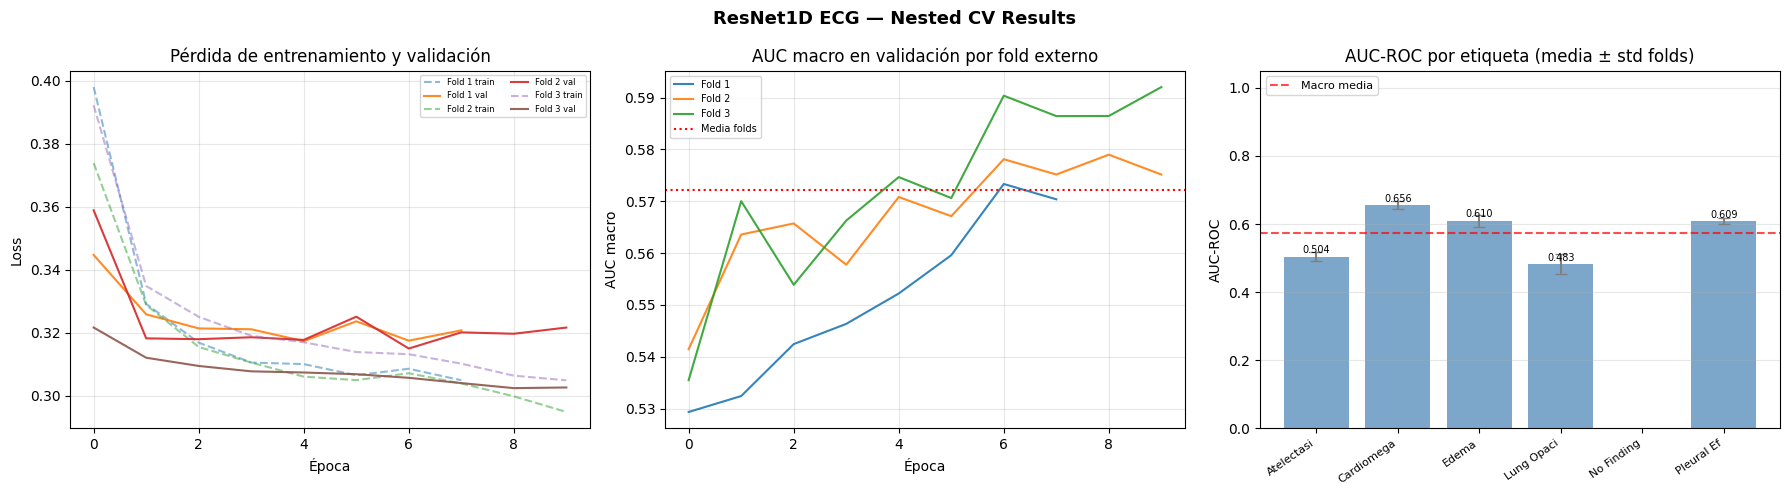

Figura guardada: outputs_resnet1d_ecg\ecg_nested_cv_results.png


In [30]:
auc_macros = [r['test_metrics']['macro_AUC'] for r in outer_results]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('ResNet1D ECG — Nested CV Results', fontsize=13, fontweight='bold')

# ── Curvas de pérdida ────────────────────────────────────────────────────────
ax = axes[0]
for r in outer_results:
    h = r['history']
    ax.plot(h['train_loss'], linestyle='--', alpha=0.5, label=f'Fold {r["outer_fold"]} train')
    ax.plot(h['val_loss'],                  alpha=0.9, label=f'Fold {r["outer_fold"]} val')
ax.set_xlabel('Época')
ax.set_ylabel('Loss')
ax.set_title('Pérdida de entrenamiento y validación')
ax.legend(fontsize=6, ncol=2)
ax.grid(alpha=0.3)

# ── AUC macro por época ──────────────────────────────────────────────────────
ax = axes[1]
for r in outer_results:
    ax.plot(r['history']['val_auc_macro'], alpha=0.9, label=f'Fold {r["outer_fold"]}')
ax.axhline(np.nanmean(auc_macros), color='red', linestyle=':', label='Media folds')
ax.set_xlabel('Época')
ax.set_ylabel('AUC macro')
ax.set_title('AUC macro en validación por fold externo')
ax.legend(fontsize=7)
ax.grid(alpha=0.3)

# ── AUC por etiqueta (barras) ────────────────────────────────────────────────
ax = axes[2]
means = [np.nanmean([r['test_metrics'][l]['AUC'] for r in outer_results]) for l in LABELS]
stds  = [np.nanstd( [r['test_metrics'][l]['AUC'] for r in outer_results]) for l in LABELS]
bars  = ax.bar(range(len(LABELS)), means, yerr=stds,
               color='steelblue', alpha=0.7, capsize=4, ecolor='gray')
ax.set_xticks(range(len(LABELS)))
ax.set_xticklabels([l[:10] for l in LABELS], rotation=35, ha='right', fontsize=8)
ax.set_ylabel('AUC-ROC')
ax.set_title('AUC-ROC por etiqueta (media ± std folds)')
ax.set_ylim([0, 1.05])
ax.axhline(np.nanmean(auc_macros), color='red', linestyle='--', alpha=0.7, label='Macro media')
ax.legend(fontsize=8)
ax.grid(alpha=0.3, axis='y')
for bar, val in zip(bars, means):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{val:.3f}', ha='center', fontsize=7)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'ecg_nested_cv_results.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Figura guardada: {OUTPUT_DIR / "ecg_nested_cv_results.png"}')

## Celda 17 — Evaluación final en test set oficial

> ⚠️ **Ejecutar esta celda una sola vez.** Selecciona el fold externo con mayor AUC,
> carga su checkpoint y evalúa sobre el test set oficial no visto durante el CV.

In [32]:
auc_macros = [r['test_metrics']['macro_AUC'] for r in outer_results]

print('\n' + '='*70)
print('  EVALUACIÓN FINAL EN TEST SET OFICIAL')
print('  EJECUTAR ESTA CELDA UNA SOLA VEZ.')
print('='*70)

# Seleccionar el fold externo con mejor AUC
best_idx        = int(np.argmax(auc_macros))
best_outer_fold = outer_results[best_idx]
print(f'\n  Fold seleccionado   : {best_outer_fold["outer_fold"]}  '
      f'(AUC_outer={auc_macros[best_idx]:.4f})')

# ── [FIX] weights_only=False — checkpoint propio y de confianza ───────────────
# PyTorch >=2.6 cambió el default a weights_only=True, lo que bloquea
# la carga de objetos no-tensor (dicts con best_config, thresholds, etc.)
ckpt     = torch.load(best_outer_fold['checkpoint'], map_location=DEVICE,
                      weights_only=False)
best_cfg = ckpt['best_config']

model_test = ECGResNet1D(
    n_labels=N_LABELS,
    dropout_rate=best_cfg['dropout_rate'],
    use_label_correlation=best_cfg['use_label_correlation'],
    use_meta_branch=best_cfg['use_meta_branch'],
).to(DEVICE)
model_test.load_state_dict(ckpt['model_state_dict'])

best_thresholds_test = np.array(ckpt['thresholds'])

# DataLoader del test oficial
aug_test    = ECGAugmentation(level='none')
ds_test_off = ECGMultilabelDataset(
    df_test, ecg_test_npy, aug_test,
    uncertainty_policy=best_cfg['uncertainty_policy']
)
criterion_test = build_criterion(best_cfg)
loader_test    = DataLoader(ds_test_off, batch_size=64, shuffle=False, num_workers=0)
print(f'  Test samples : {len(ds_test_off):,}')

_, test_probs_f, test_labels_f, test_masks_f = evaluate(
    model_test, loader_test, criterion_test, best_cfg, desc='Test oficial'
)
test_metrics_final = compute_multilabel_metrics(
    test_probs_f, test_labels_f, test_masks_f, thresholds=best_thresholds_test
)

# ── Imprimir métricas finales ─────────────────────────────────────────────────
print('\n  MÉTRICAS FINALES EN TEST OFICIAL:')
print(f'  {"Etiqueta":22s} | {"AUC":>6} | {"AP":>6} | {"F1":>6} | {"N+":>5} | {"N-":>5}')
print('  ' + '-'*60)
for lbl in LABELS:
    m     = test_metrics_final[lbl]
    auc_s = f'{m["AUC"]:.4f}' if not np.isnan(m['AUC']) else '  N/A '
    ap_s  = f'{m["AP"]:.4f}'  if not np.isnan(m['AP'])  else '  N/A '
    print(f'  {lbl:22s} | {auc_s:>6} | {ap_s:>6} | {m["F1"]:>6.4f} | '
          f'{m["n_pos"]:>5} | {m["n_neg"]:>5}')
print('  ' + '-'*60)
print(f'  {"MACRO":22s} | {test_metrics_final["macro_AUC"]:>6.4f} | '
      f'{test_metrics_final["macro_AP"]:>6.4f} | {test_metrics_final["macro_F1"]:>6.4f}')

# ── Umbral tau para "No Finding" (etiqueta derivada) ─────────────────────────
print('\n  Determinando umbral τ para No Finding (etiqueta derivada)...')
pathology_indices = [i for i, l in enumerate(LABELS) if l != 'No Finding']
no_finding_true   = (test_labels_f[:, LABELS.index('No Finding')] == 1).astype(int)
max_pathol_probs  = test_probs_f[:, pathology_indices].max(axis=1)

best_tau, best_tau_f1 = 0.5, -1
for tau in np.linspace(0.05, 0.95, 50):
    no_finding_pred = (max_pathol_probs < tau).astype(int)
    if no_finding_true.sum() > 0:
        f1_tau = f1_score(no_finding_true, no_finding_pred, zero_division=0)
        if f1_tau > best_tau_f1:
            best_tau_f1 = f1_tau
            best_tau    = tau

print(f'  Umbral τ óptimo  : {best_tau:.3f}  (F1={best_tau_f1:.4f} sobre test)')

# ── Guardar resultados finales ────────────────────────────────────────────────
with open(OUTPUT_DIR / 'ecg_final_test_results.json', 'w') as f:
    json.dump({
        'macro_AUC'     : test_metrics_final['macro_AUC'],
        'macro_AP'      : test_metrics_final['macro_AP'],
        'macro_F1'      : test_metrics_final['macro_F1'],
        'per_label'     : {lbl: test_metrics_final[lbl] for lbl in LABELS},
        'no_finding_tau': best_tau,
        'best_config'   : best_cfg,
    }, f, indent=2, default=str)
print(f'  Resultados finales guardados en: {OUTPUT_DIR / "ecg_final_test_results.json"}')


  EVALUACIÓN FINAL EN TEST SET OFICIAL
  EJECUTAR ESTA CELDA UNA SOLA VEZ.

  Fold seleccionado   : 3  (AUC_outer=0.5864)
  Usando Masked BCE
  Test samples : 464



  MÉTRICAS FINALES EN TEST OFICIAL:
  Etiqueta               |    AUC |     AP |     F1 |    N+ |    N-
  ------------------------------------------------------------
  Atelectasis            | 0.4695 | 0.9670 | 0.6351 |   141 |     5
  Cardiomegaly           | 0.6435 | 0.8301 | 0.7082 |   144 |    50
  Edema                  | 0.6416 | 0.6428 | 0.5876 |    82 |    88
  Lung Opacity           | 0.6095 | 0.9480 | 0.9451 |   131 |    13
  No Finding             |   N/A  |   N/A  | 1.0000 |    69 |     0
  Pleural Effusion       | 0.6062 | 0.7323 | 0.6034 |   166 |    90
  ------------------------------------------------------------
  MACRO                  | 0.5941 | 0.8240 | 0.7465

  Determinando umbral τ para No Finding (etiqueta derivada)...
  Umbral τ óptimo  : 0.656  (F1=0.2850 sobre test)
  Resultados finales guardados en: outputs_resnet1d_ecg\ecg_final_test_results.json


## Celda 18 — Análisis de equidad por subgrupo demográfico

Calcula AUC macro y F1 macro desglosados por género, raza y tipo de admisión,
usando las predicciones obtenidas en la evaluación del test oficial (Celda 17).

In [34]:
df_test_r = df_test.reset_index(drop=True)

for col, vals, label in [
    ('gender',         [0, 1],                    'GÉNERO'),
    ('race',           list(RACE_MAP.keys()),      'RAZA'),
    ('admission_type', list(ADMISSION_MAP.keys()), 'TIPO ADMISIÓN'),
]:
    print(f'\nAUC macro por {label}')
    for v in vals:
        idx = df_test_r[df_test_r[col] == v].index.values
        if len(idx) < 20:
            print(f'  {str(v):25s}: n={len(idx)} (insuficiente para métricas robustas)')
            continue
        m = compute_multilabel_metrics(
            test_probs_f[idx], test_labels_f[idx], test_masks_f[idx],
            thresholds=best_thresholds_test
        )
        print(f'  {str(v):25s} (n={len(idx):4d}): '
              f'AUC={m["macro_AUC"]:.4f}  F1={m["macro_F1"]:.4f}')

print('\nAnálisis de equidad por subgrupo completado.')


AUC macro por GÉNERO
  0                         (n= 184): AUC=0.6360  F1=0.7837
  1                         (n= 280): AUC=0.6091  F1=0.7167

AUC macro por RAZA
  UNKNOWN                   (n=  52): AUC=0.4718  F1=0.7171
  WHITE                     (n= 315): AUC=0.5993  F1=0.7446
  BLACK                     (n=  58): AUC=0.7420  F1=0.7043
  ASIAN                    : n=15 (insuficiente para métricas robustas)
  HISPANIC_LATINO           (n=  21): AUC=0.5409  F1=0.7044
  OTHER_KNOWN              : n=3 (insuficiente para métricas robustas)

AUC macro por TIPO ADMISIÓN
  SCHEDULED                 (n=  34): AUC=0.3944  F1=0.5682
  EMERGENCY                 (n= 322): AUC=0.6284  F1=0.7517
  OBSERVATION               (n=  66): AUC=0.6340  F1=0.6462
  URGENT                    (n=  42): AUC=0.7917  F1=0.8408

Análisis de equidad por subgrupo completado.
